# EgoDyn-Bench — Model Failure Analysis

A model post-mortem walkthrough. Pick any model that has a `results/<model>.json`
file and the notebook will produce:

1. **Per-question performance breakdown** — which categories does this model fail on?
2. **Confusion matrices per question** — which classes get confused with which?
3. **Raw misprediction examples** — pulled from `generated/<model>_answers.jsonl`.
4. **Consistency-rule violations** — which physics rules from `leaderboard/results.json` fire?
5. **Comparison context** — ranking position and per-question delta vs. the model's `_w_traj` (or vision-only) counterpart, if one exists.

The model is chosen via a dropdown — change it and click **Run All Below** to refresh
the five sections.

> **Note on outputs:** the dropdown is for *interactive* use. For static
> viewing (GitHub preview etc.) the cells render the model that was selected
> at the time the notebook was last executed.

In [1]:
"""Bootstrap: imports, project-root resolution, data loading."""
%matplotlib inline

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

# Walk up until we find the project root.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "selected_clips.json").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError(f"Project root not found from {Path.cwd()}")
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

# These scripts call matplotlib.use("Agg") on import — restore inline after.
from scripts.visualize_website import (
    load_results, QUESTION_LABELS, MODEL_LABELS, _color, _label,
)
from evaluation.parsers import load_question_config, parse_answer
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 10,
})

# Load all results and the question schema (choices + answer types per qid).
results = load_results(PROJECT_ROOT / "results")
question_config = load_question_config(
    PROJECT_ROOT / "dataset" / "configs" / "questions_template.yaml"
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded {len(results)} model results, {len(question_config)} questions")


Project root: /home/finn-avs1/Documents/coding/dynamic-trajectory-understanding
Loaded 58 model results, 14 questions


## Model selector

The dropdown lists every model with a result file. Models are ordered by
overall balanced accuracy (best first). Changing the dropdown updates the
`MODEL` variable; re-run the cells below to regenerate the plots.

In [2]:
# Order models by global balanced_acc (best first).
available_models = sorted(
    results.keys(),
    key=lambda k: -results[k]["global"]["balanced_acc"],
)

# Pretty labels (with metrics) for the dropdown.
def _display(m):
    bacc = results[m]["global"]["balanced_acc"]
    f1   = results[m]["global"]["macro_f1"]
    return f"{m}   (BAcc={bacc:.3f}, F1={f1:.3f})"

selector = widgets.Dropdown(
    options=[(_display(m), m) for m in available_models],
    value="gemini3_pro_w_traj" if "gemini3_pro_w_traj" in results else available_models[0],
    description="Model:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px"),
)
display(selector)

# Track the current selection in a global variable that subsequent cells use.
MODEL = selector.value

def _on_model_change(change):
    if change.get("name") == "value":
        global MODEL
        MODEL = change["new"]
        print(f"MODEL set to: {MODEL}\nClick \"Run All Below\" to refresh the analyses.")

selector.observe(_on_model_change)
print(f"Initial MODEL: {MODEL}")


Dropdown(description='Model:', layout=Layout(width='500px'), options=(('gemini3_pro_w_traj   (BAcc=0.683, F1=0…

Initial MODEL: gemini3_pro_w_traj


## 1. Per-question performance breakdown

Which of the 14 question types does this model handle well, and which
trip it up? We plot balanced accuracy per question, sorted from worst to
best. A horizontal line marks the model's overall (across-question)
balanced accuracy as a reference.

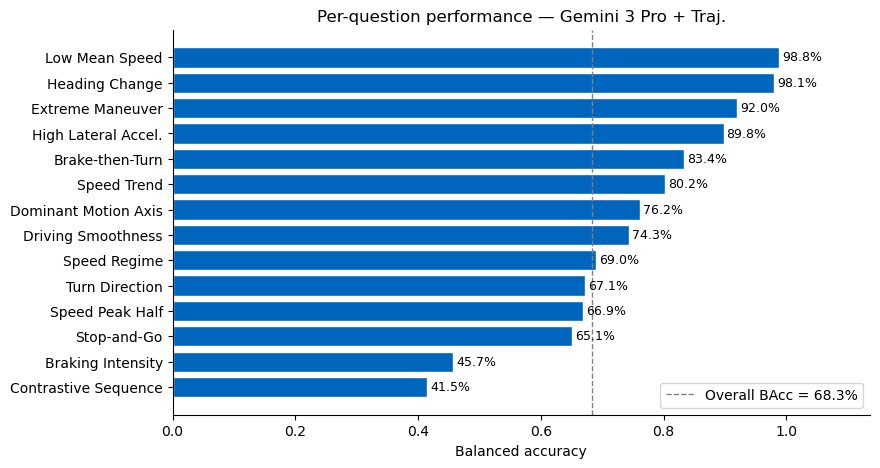

In [3]:
def render_per_question(model: str) -> None:
    r = results[model]
    pq = r["per_question"]
    qids = sorted(pq, key=lambda q: pq[q]["balanced_acc"])
    baccs = [pq[q]["balanced_acc"] for q in qids]
    labels = [QUESTION_LABELS.get(q, q).replace("\n", " ") for q in qids]
    overall = r["global"]["balanced_acc"]

    fig, ax = plt.subplots(figsize=(9, 5))
    y = np.arange(len(qids))
    bars = ax.barh(y, baccs, color=_color(model), edgecolor="white")
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.axvline(overall, color="grey", ls="--", lw=1,
               label=f"Overall BAcc = {overall:.1%}")
    for bar, v in zip(bars, baccs):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{v:.1%}", va="center", fontsize=9)
    ax.set_xlim(0, max(baccs) * 1.15)
    ax.set_xlabel("Balanced accuracy")
    ax.set_title(f"Per-question performance — {_label(model)}")
    ax.legend(loc="lower right")
    plt.show()

render_per_question(MODEL)


## 2. Confusion matrices per question

A bar chart hides the *kind* of error. The confusion matrices below show
exactly which classes the model swaps with which, per question. Rows are
oracle labels (ground truth), columns are model predictions, values are
counts. Diagonal-heavy = good; off-diagonal mass shows the failure mode.

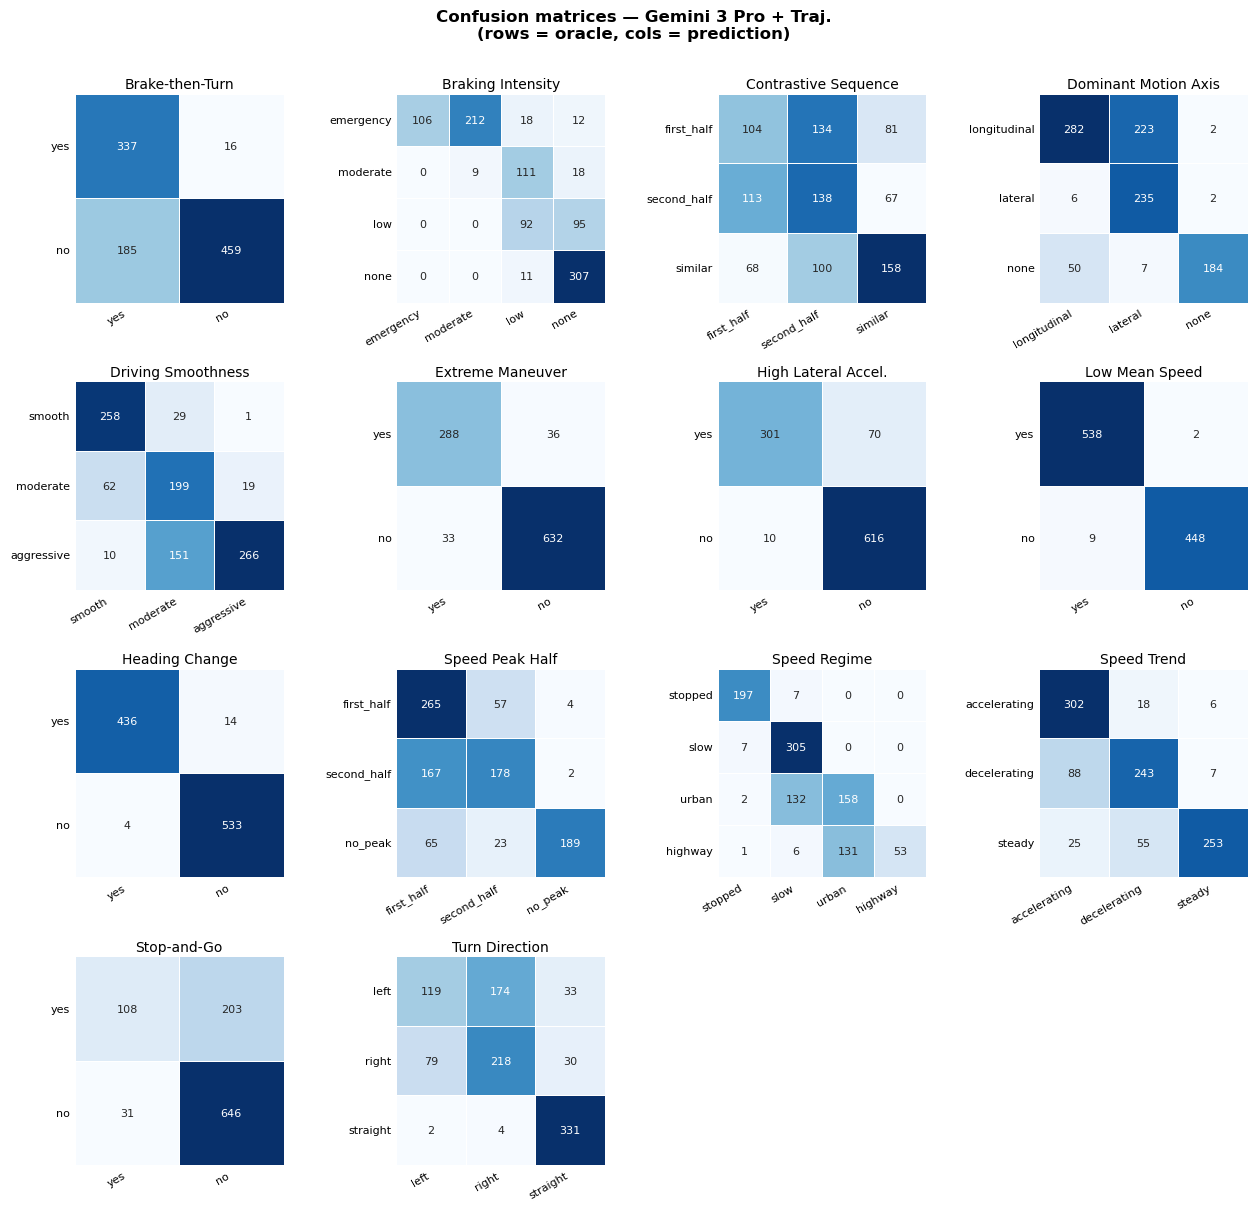

In [4]:
def render_confusion_matrices(model: str) -> None:
    pq = results[model]["per_question"]
    qids = sorted(pq.keys())

    ncols, nrows = 4, 4  # 14 questions fit in 4×4 with 2 empty
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 12))
    axes = axes.flatten()

    for ax, qid in zip(axes, qids):
        cm = pq[qid].get("confusion_matrix")
        if cm is None:
            ax.set_visible(False)
            continue
        labels = cm["labels"]
        mat = np.array(cm["matrix"])
        sns.heatmap(mat, ax=ax, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=labels, yticklabels=labels,
                    annot_kws={"fontsize": 8}, linewidths=0.5,
                    linecolor="white", square=True)
        ax.set_title(QUESTION_LABELS.get(qid, qid).replace("\n", " "),
                     fontsize=10, pad=4)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right",
                           fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
        ax.tick_params(length=0)

    for ax in axes[len(qids):]:
        ax.set_visible(False)

    fig.suptitle(f"Confusion matrices — {_label(model)}\n"
                 f"(rows = oracle, cols = prediction)",
                 fontsize=12, fontweight="bold", y=1.005)
    fig.tight_layout()
    plt.show()

render_confusion_matrices(MODEL)


## 3. Raw misprediction examples

What does the model *actually say* when it gets the answer wrong? We
load the raw `generated/<model>_answers.jsonl`, parse the free-text
response with the same parser the eval harness uses
(`evaluation.parsers.parse_answer`), and print up to 10 examples where
`parsed_prediction ≠ oracle_label`.

If no answers file is present (some models are excluded from the
`generated/` directory because they were re-evaluated via the leaderboard
pipeline only), the cell prints a hint instead of failing.

In [5]:
ANSWERS_DIR = PROJECT_ROOT / "generated"

def _find_answers_file(model: str) -> Path | None:
    for name in (f"{model}_answers.jsonl", f"{model}.jsonl"):
        p = ANSWERS_DIR / name
        if p.exists():
            return p
    return None


def render_mispredictions(model: str, n_per_question: int = 1,
                          n_total: int = 12) -> None:
    answers_path = _find_answers_file(model)
    if answers_path is None:
        print(f"  No answers file found for '{model}' in {ANSWERS_DIR}/")
        print(f"  Looked for: {model}_answers.jsonl, {model}.jsonl")
        return

    print(f"Loading {answers_path.name} ...")
    rows = []
    with open(answers_path) as f:
        for line in f:
            rec = json.loads(line)
            qcfg = question_config.get(rec["question_id"])
            if qcfg is None:
                continue
            pred = parse_answer(rec.get("model_answer", ""),
                                qcfg["choices"], qcfg["answer_type"])
            if pred is None or pred == rec["oracle_label"]:
                continue
            rows.append({
                "clip_id":    rec["clip_id"],
                "question":   rec["question_id"],
                "oracle":     rec["oracle_label"],
                "predicted":  pred,
                "model_text": rec["model_answer"][:180].replace("\n", " "),
            })

    if not rows:
        print(f"  No mispredictions found (or none parseable).")
        return

    df = pd.DataFrame(rows)
    # Sample up to n_per_question per question (spread coverage), then trim.
    sampled = (df.groupby("question", group_keys=False)
                 .apply(lambda g: g.sample(min(n_per_question, len(g)),
                                            random_state=0))
                 .reset_index(drop=True)
                 .head(n_total))

    print(f"Total mispredictions parsed: {len(df)} of {len(df) + 0}")
    print(f"Showing {len(sampled)} sampled (one-per-question, capped at {n_total}):\n")
    pd.set_option("display.max_colwidth", 200)
    pd.set_option("display.max_rows", n_total)
    display(sampled)

render_mispredictions(MODEL)


Loading gemini3_pro_w_traj.jsonl ...
Total mispredictions parsed: 3340 of 3340
Showing 12 sampled (one-per-question, capped at 12):



/tmp/ipykernel_1970468/193142236.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(n_per_question, len(g)),


,clip_id,question,oracle,predicted,model_text
0,clip_02357,brake_then_turn,no,yes,yes
1,clip_01290,braking_intensity,moderate,low,low
2,HRV_Centar-59_1_T-4__Efficiency-Sporty__w3,contrastive_sequence,first_half,second_half,second_half
3,clip_09740,dominant_motion_axis,longitudinal,lateral,lateral
4,DEU_Kitzingen-34_1_T-3__Safety-Conservative__w2,driving_smoothness,aggressive,moderate,moderate
5,USA_Lanker-2_3_T-1__Balanced__w0,extreme_maneuver,no,yes,yes
6,DEU_Herzogenaurach-175_1_T-17__Default__w0,high_lateral_accel,yes,no,no
7,DEU_Heilbronn-258_1_T-17__Default__w1,mean_speed_low,no,yes,yes
8,CAN_Ottawa-63_1_T-24__Safety-Conservative__w1,significant_heading_change,no,yes,yes
9,DEU_Memmingen-125_1_T-2__Balanced__w1,speed_peak_half,second_half,first_half,first_half


## 4. Consistency-rule violations

The benchmark's WEMCR metric checks whether a model's answers obey
physical-consistency rules (e.g. "if `brake_then_turn = yes` then
`braking_intensity ≠ none`"). Rule-level compliance per model is stored
in `leaderboard/results.json` as `rule_<rule_name>_{trigger,violations,compliance}`
triples. Below we plot per-rule compliance for the selected model, sorted
from least compliant to most.

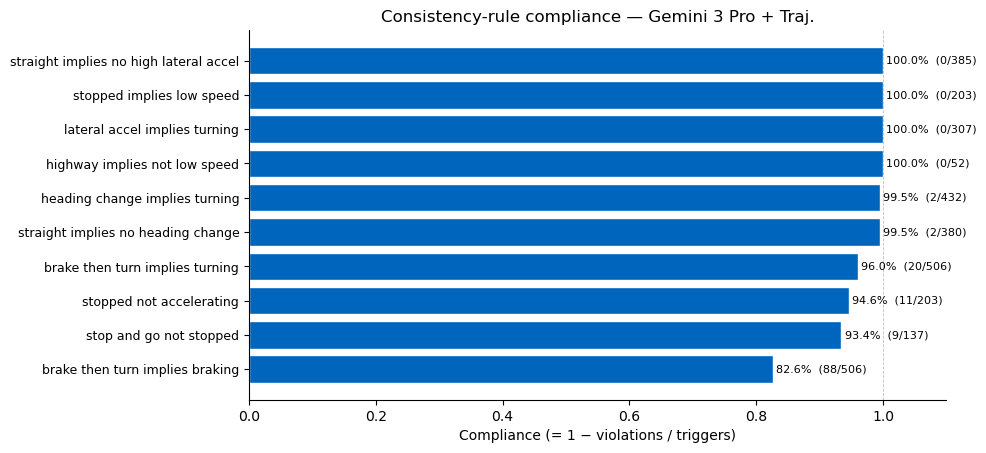

In [6]:
with open(PROJECT_ROOT / "leaderboard" / "results.json") as f:
    leaderboard = {entry["model"]: entry for entry in json.load(f)}


def render_rule_compliance(model: str) -> None:
    if model not in leaderboard:
        print(f"  Model '{model}' missing from leaderboard/results.json — "
              f"skipping rule compliance.")
        return

    entry = leaderboard[model]
    rule_keys = sorted({k.removesuffix("_compliance")
                        for k in entry if k.endswith("_compliance")
                        and k.startswith("rule_")})
    if not rule_keys:
        print(f"  No rule_* fields for {model}.")
        return

    rows = [{
        "rule":        rk.removeprefix("rule_").replace("_", " "),
        "compliance":  entry.get(f"{rk}_compliance", float("nan")),
        "triggers":    entry.get(f"{rk}_trigger", 0),
        "violations":  entry.get(f"{rk}_violations", 0),
    } for rk in rule_keys]
    rows.sort(key=lambda r: r["compliance"])

    fig, ax = plt.subplots(figsize=(9, max(3, 0.42 * len(rows) + 0.6)))
    y = np.arange(len(rows))
    comps = [r["compliance"] for r in rows]
    color = _color(model)
    bars = ax.barh(y, comps, color=color, edgecolor="white")
    ax.set_yticks(y)
    ax.set_yticklabels([r["rule"] for r in rows], fontsize=9)
    ax.axvline(1.0, color="grey", ls="--", lw=0.6, alpha=0.5)
    for bar, r in zip(bars, rows):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{r['compliance']:.1%}  ({r['violations']}/{r['triggers']})",
                va="center", fontsize=8)
    ax.set_xlim(0, 1.10)
    ax.set_xlabel("Compliance (= 1 − violations / triggers)")
    ax.set_title(f"Consistency-rule compliance — {_label(model)}")
    plt.show()

render_rule_compliance(MODEL)


## 5. Comparison context

How does this model sit relative to its peers, and does adding (or
removing) trajectory text help? Two views:

- **Ranking** — every model's overall balanced accuracy, with the
  selected model highlighted.
- **Per-question delta vs. counterpart** — if the selected model has a
  `<model>_w_traj` (or vision-only) sibling, we plot the per-question
  balanced-accuracy difference. Positive bars mean the *current* model
  is better on that question.

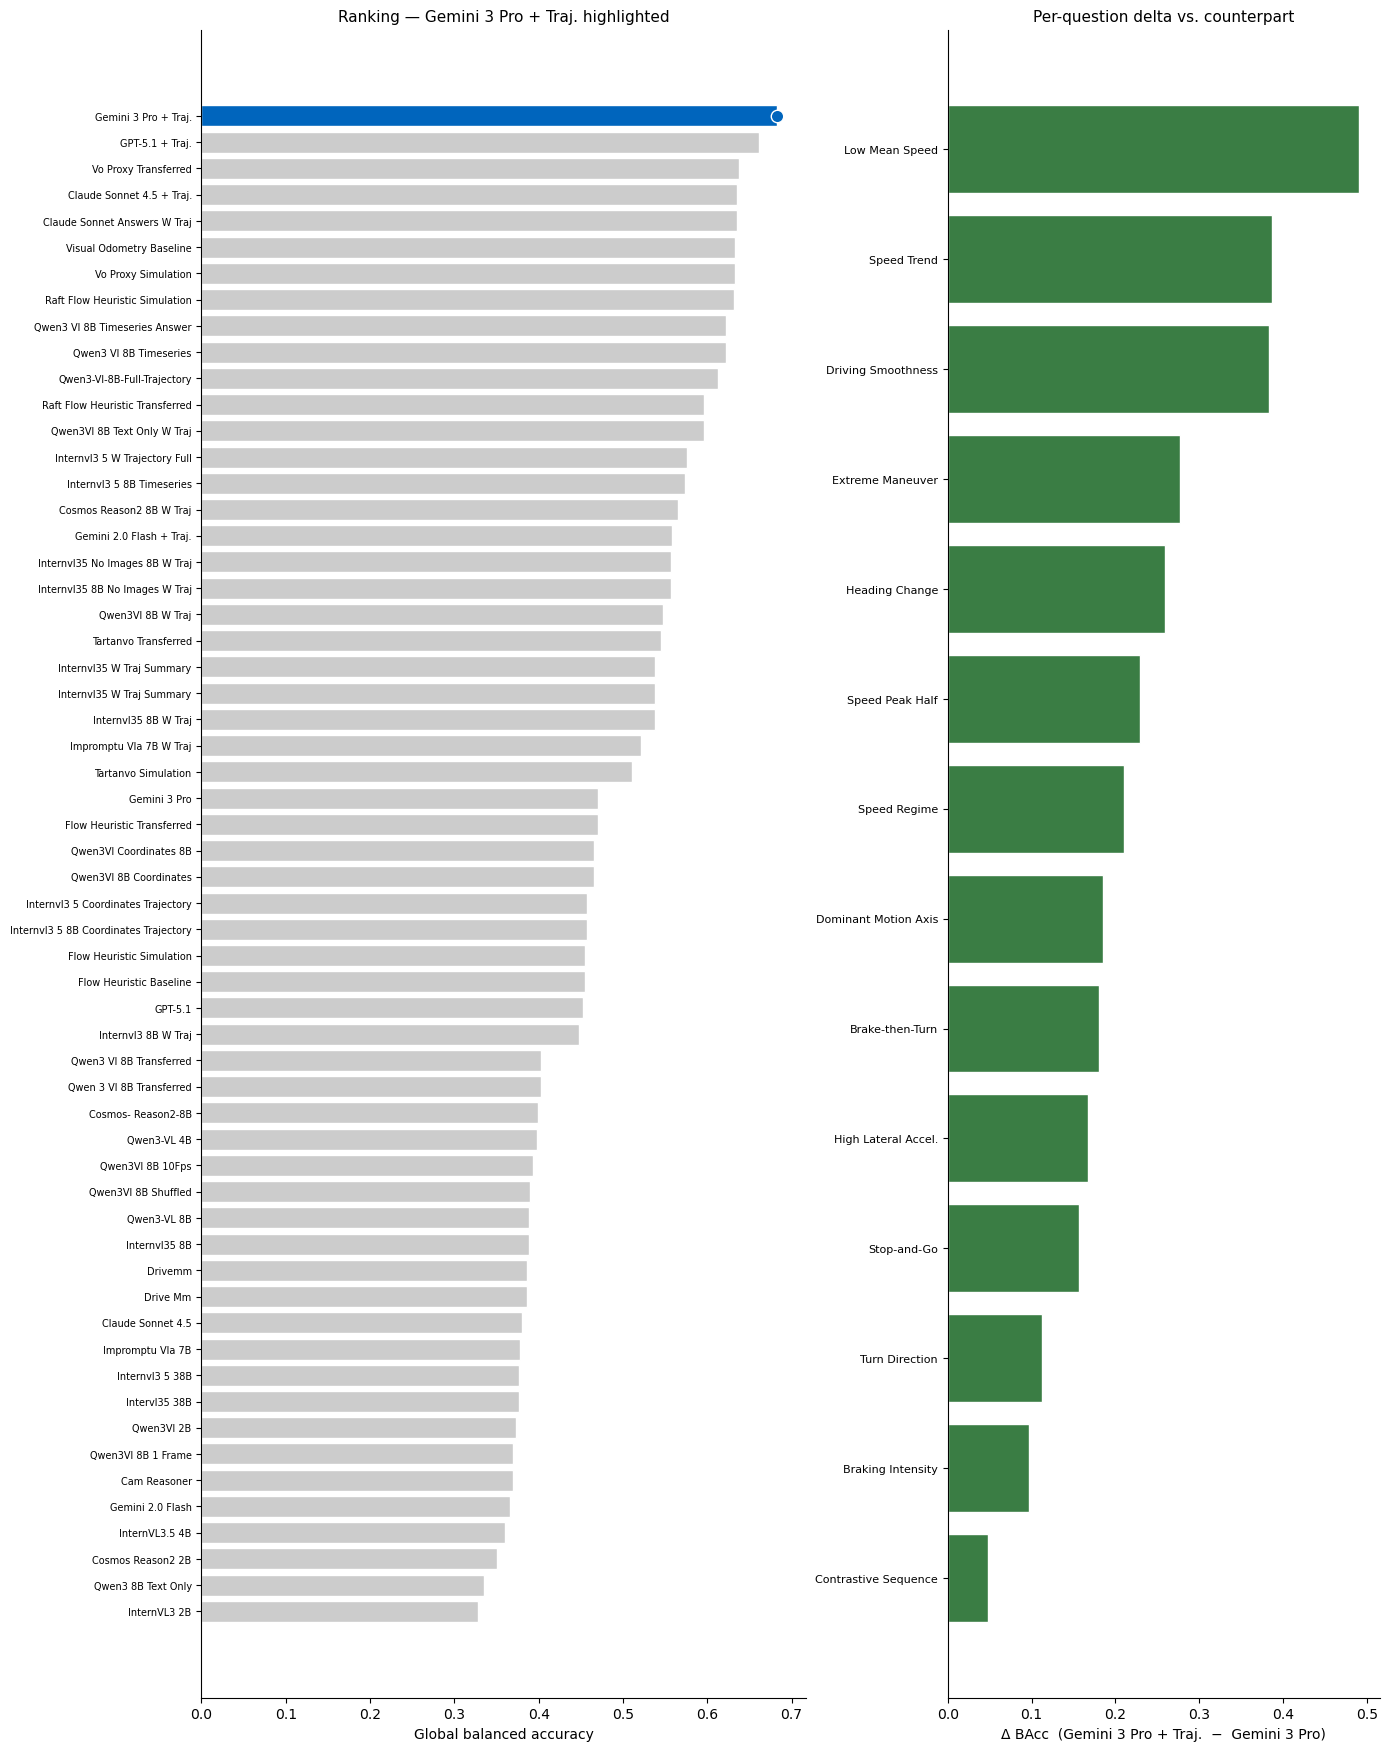

In [7]:
def _counterpart(model: str) -> str | None:
    if model.endswith("_w_traj"):
        cp = model[: -len("_w_traj")]
    else:
        cp = f"{model}_w_traj"
    return cp if cp in results else None


def render_comparison(model: str) -> None:
    # Panel A: ranking
    order = sorted(results.keys(),
                   key=lambda k: results[k]["global"]["balanced_acc"])
    baccs = [results[m]["global"]["balanced_acc"] for m in order]
    colors = [_color(m) if m == model else "#cccccc" for m in order]
    labels = [_label(m) for m in order]

    cp = _counterpart(model)
    has_cp = cp is not None
    fig = plt.figure(figsize=(14, max(6, 0.30 * len(order))),
                     constrained_layout=True)
    gs = fig.add_gridspec(1, 3 if has_cp else 1,
                          width_ratios=[1.4, 1, 0.05] if has_cp else [1])

    ax_rank = fig.add_subplot(gs[0, 0])
    y = np.arange(len(order))
    ax_rank.barh(y, baccs, color=colors, edgecolor="white")
    ax_rank.set_yticks(y)
    ax_rank.set_yticklabels(labels, fontsize=7)
    ax_rank.set_xlabel("Global balanced accuracy")
    ax_rank.set_title(f"Ranking — {_label(model)} highlighted",
                      fontsize=11)
    # Mark the selected model with a marker.
    if model in order:
        idx = order.index(model)
        ax_rank.scatter(baccs[idx], idx, color=_color(model), s=80,
                        marker="o", zorder=5, edgecolors="white")

    # Panel B: per-question delta vs counterpart
    if has_cp:
        ax_delta = fig.add_subplot(gs[0, 1])
        qids = sorted(results[model]["per_question"].keys())
        m_pq  = results[model]["per_question"]
        cp_pq = results[cp]["per_question"]
        deltas = [m_pq[q]["balanced_acc"] - cp_pq[q]["balanced_acc"]
                  for q in qids]
        ylabels = [QUESTION_LABELS.get(q, q).replace("\n", " ") for q in qids]
        order_d = np.argsort(deltas)
        deltas = [deltas[i] for i in order_d]
        ylabels = [ylabels[i] for i in order_d]
        bar_colors = ["#3a7d44" if d >= 0 else "#c1494a" for d in deltas]
        yy = np.arange(len(deltas))
        ax_delta.barh(yy, deltas, color=bar_colors, edgecolor="white")
        ax_delta.set_yticks(yy)
        ax_delta.set_yticklabels(ylabels, fontsize=8)
        ax_delta.axvline(0, color="grey", lw=0.5)
        ax_delta.set_xlabel(f"Δ BAcc  ({_label(model)}  −  {_label(cp)})")
        ax_delta.set_title("Per-question delta vs. counterpart",
                           fontsize=11)
    else:
        print(f"  No counterpart found for '{model}' — skipping per-question delta panel.")

    plt.show()

render_comparison(MODEL)


## Next steps

- **`statistics.ipynb`** — explore the dataset that produced these results.
- **`scripts/clip_viewer.py`** — open a specific `clip_id` from the
  mispredictions table in the interactive browser to inspect the underlying
  video + dynamics.
- **`evaluation/parsers.py` / `evaluation/metrics.py`** — the harness functions
  these analyses build on.
- **`docs/EVALUATION.md`** — how to add your own model and produce a new
  `results/<your_model>.json` + `generated/<your_model>_answers.jsonl`.